In [20]:
## Add imports here
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import random
from collections import Counter
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import os
import copy
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 128
############################## Extra stuff #################################
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(FeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        
    def split_heads(self, x, batch_size):
        return x.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
    def merge_heads(self, x, batch_size):
        return x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
    
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        q = self.W_q(q)
        k = self.W_k(k)
        v = self.W_v(v)
        
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        
        # Scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        output = torch.matmul(attn_weights, v)
        output = self.merge_heads(output, batch_size)
        output = self.W_o(output)
        
        return output, attn_weights

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        attn_output, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=512, num_heads=8, num_layers=6, d_ff=2048, max_seq_length=MAX_LEN, dropout=0.1):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)
        self.dropout = nn.Dropout(dropout)
        
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        self.fc = nn.Linear(d_model, vocab_size)
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
                
    def make_causal_mask(self, seq_len):
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        return ~mask
        
    def forward(self, x):
        seq_len = x.size(1)
        mask = self.make_causal_mask(seq_len).to(DEVICE)
        
        # Embedding and positional encoding
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.dropout(x)
        
        # Encoder layers
        attentions = []
        for encoder_layer in self.encoder_layers:
            x = encoder_layer(x, mask)
            
        # Final linear layer
        output = self.fc(x)
        
        return output, attentions
########################################
def initialise_projections(d_model, num_heads):
    """
    Create projections for Q, K, V.
    """
    d_k = d_model // num_heads
    W_q = nn.Linear(d_model, d_model)
    W_k = nn.Linear(d_model, d_model)
    W_v = nn.Linear(d_model, d_model)
    W_o = nn.Linear(d_model, d_model)
    
    return W_q, W_k, W_v, W_o

def pairwise_similarities(q, k):
    """
    Compute dot product attention.
    """
    # q shape: (batch_size, num_heads, seq_len, d_k)
    # k shape: (batch_size, num_heads, seq_len, d_k)
    # Output shape: (batch_size, num_heads, seq_len, seq_len)
    return torch.matmul(q, k.transpose(-2, -1))
    
def attention_scaled(similarities, d_k):
    """
    Scale the raw attention scores.
    """
    return similarities / math.sqrt(d_k)
    
def attention_softmax(scaled_similarities, mask=None):
    """
    Normalize the scaled raw attention scores with softmax.
    """
    if mask is not None:
        scaled_similarities = scaled_similarities.masked_fill(mask == 0, -1e9)
    return F.softmax(scaled_similarities, dim=-1)

def compute_outputs(attention_weights, v):
    """
    Get outputs as a weighted sum of values by attention scores.
    """
    # attention_weights shape: (batch_size, num_heads, seq_len, seq_len)
    # v shape: (batch_size, num_heads, seq_len, d_k)
    # Output shape: (batch_size, num_heads, seq_len, d_k)
    return torch.matmul(attention_weights, v)

def make_causal_mask(seq_len):
    """
    Create a mask matrix that masks future context for the attention.
    """
    # Create a lower triangular matrix with 1s (including the diagonal)
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return ~mask  # Invert to get the causal mask

def apply_causal_mask(attention_scores, mask):
    """
    Apply mask to attention.
    """
    return attention_scores.masked_fill(mask == 0, -1e9)

def split_heads(x, batch_size, num_heads, d_k):
    """
    Splitting the input across multiple heads.
    """
    # x shape: (batch_size, seq_len, d_model)
    # Output shape: (batch_size, num_heads, seq_len, d_k)
    return x.view(batch_size, -1, num_heads, d_k).transpose(1, 2)

def merge_heads(x, batch_size, d_model):
    """
    Reversing splitting action of function split_heads().
    """
    # x shape: (batch_size, num_heads, seq_len, d_k)
    # Output shape: (batch_size, seq_len, d_model)
    return x.transpose(1, 2).contiguous().view(batch_size, -1, d_model)

def self_attention(q, k, v, mask=None, dropout=None):
    """
    Self-attention block.
    """
    d_k = q.size(-1)
    scores = pairwise_similarities(q, k)
    scores = attention_scaled(scores, d_k)
    
    if mask is not None:
        scores = apply_causal_mask(scores, mask)
        
    attention = attention_softmax(scores)
    
    if dropout is not None:
        attention = dropout(attention)
        
    return compute_outputs(attention, v), attention

def split_heads_qkv(q, k, v, batch_size, num_heads, d_k):
    """
    Split Q, K, V across multiple heads.
    """
    q = split_heads(q, batch_size, num_heads, d_k)
    k = split_heads(k, batch_size, num_heads, d_k)
    v = split_heads(v, batch_size, num_heads, d_k)
    return q, k, v

class ShakespeareDataset(Dataset):
    def __init__(self, data):
        self.data = data
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        return self.data[idx]

def load_and_preprocess_data():
    with open("/raid/home/ganeshb/A3/content/shakespear_train.txt", "r") as f:
        lines_train = f.readlines()
    with open("/raid/home/ganeshb/A3/content/shakespear_dev.txt", "r") as f:
        lines_dev = f.readlines()
    
    # Utility function to flatten tokens
    def flat(tokens):
        return [token for line in tokens for token in line]

    tokens_train = [line.split() for line in lines_train]
    token_counts = Counter(flat(tokens_train))
    
    # Define special tokens consistently
    special_tokens = ["<PAD>", "<START>", "<STOP>", "<UNK>"]
    
    # Create vocabulary with special tokens
    vocab = special_tokens + [word for word, count in token_counts.most_common()]
    
    # Create tokenizer
    tokenizer = {word: i for i, word in enumerate(vocab)}
    
    # Create inverse tokenizer for decoding
    tokenizer_inv = {i: word for word, i in tokenizer.items()}
    
    # Print some tokenizer information for debugging
    print(f"Vocabulary size: {len(vocab)}")
    print(f"Special tokens in tokenizer: {[(token, tokenizer[token]) for token in special_tokens]}")
    
    # Prepare datasets
    data_train = [' '.join(line.split()) for line in lines_train]
    data_val = [' '.join(line.split()) for line in lines_dev]
    
    # Create input-output pairs
    train_dataset = ShakespeareDataset(data_train)
    val_dataset = ShakespeareDataset(data_val)
    
    return train_dataset, val_dataset, tokenizer, tokenizer_inv

def pad_to_length(tokens, max_len, tokenizer):
    """
    Pad tokens to a fixed length.
    """
    if len(tokens) >= max_len:
        return tokens[:max_len]
    else:
        return tokens + [tokenizer["<PAD>"]] * (max_len - len(tokens))

def tokenize(sentence, pad_to_len=None, tokenizer=None, include_stop=True):
    """
    Tokenize a sentence.
    """
    tokens = [tokenizer.get("<START>")]
    
    for word in sentence.split():
        if word in tokenizer:
            tokens.append(tokenizer[word])
        else:
            tokens.append(tokenizer["<UNK>"])
    
    if include_stop:
        tokens.append(tokenizer["<STOP>"])
    
    if pad_to_len is not None:
        tokens = pad_to_length(tokens, pad_to_len, tokenizer)
    
    return tokens


def decode(tokens, tokenizer_inv, end_at_stop=True, omit_pad=True):
    """
    Decode tokens to text.
    """
    result = []
    pad_idx = 0  # <PAD> is typically indexed as 0
    stop_idx = 2  # <STOP> is typically indexed as 2
    
    for token in tokens:
        # Check indices directly rather than looking up in tokenizer_inv
        if token == stop_idx and end_at_stop:
            break
        if token == pad_idx and omit_pad:
            continue
        if token in [0, 1, 2]:  # Skip special tokens by index
            continue
            
        # Only look up the token if it's in the valid range
        if token in tokenizer_inv:
            result.append(tokenizer_inv[token])
        else:
            result.append("<UNK>")  # Fallback for unknown tokens
    
    return ' '.join(result)
@torch.no_grad()
def evaluate_losses(data, model, tokenizer, bs=32, progress=True, pad_to_len=MAX_LEN):
    it = range(0, len(data), bs)
    if progress:
        it = tqdm(it)

    out = []
    for b_start in it:
        batch = slice(b_start, b_start + bs)
        tokens = torch.tensor(
            [tokenize(t, pad_to_len=pad_to_len, tokenizer=tokenizer) for t in data[batch]], dtype=torch.long
        ).to(DEVICE)
        X_tokens, y_tokens = tokens[:, :-1].contiguous(), tokens[:, 1:].contiguous()

        model.eval()
        logits, _ = model(X_tokens)
        log_probs = F.log_softmax(logits, dim=-1)
        y_log_probs = torch.gather(log_probs, 2, y_tokens[..., None])[..., 0]

        for i in range(y_tokens.shape[0]):
            not_pad = y_tokens[i] != tokenizer["<PAD>"]
            loss = -y_log_probs[i, not_pad].mean()
            out.append(loss.item())

    return out

def compute_perplexity(losses):
    """
    Compute perplexity from losses.
    """
    return torch.exp(torch.tensor(losses).mean()).item()

def generate_text(model, tokenizer, tokenizer_inv, context="<START>", gen_tokens=10, temperature=0.6):
    """
    Generate a fixed number of tokens using the trained model.
    """
    # Tokenize the context
    context_tokens = tokenize(context, tokenizer=tokenizer, include_stop=False)
    context_tensor = torch.tensor([context_tokens], dtype=torch.long).to(DEVICE)
    
    generated = context_tokens.copy()
    
    model.eval()
    with torch.no_grad():
        for _ in range(gen_tokens):
            # Prepare the input sequence
            curr_input = torch.tensor([generated], dtype=torch.long).to(DEVICE)
            
            # Get predictions
            logits, _ = model(curr_input)
            
            # Focus on the last token's predictions
            next_token_logits = logits[0, -1, :] / temperature
            
            # Apply softmax to get probabilities
            probabilities = F.softmax(next_token_logits, dim=-1)
            
            # Sample from the distribution
            next_token = torch.multinomial(probabilities, 1).item()
            
            # Append to the context
            generated.append(next_token)
            
            # Stop if we generated a STOP token
            if next_token == tokenizer["<STOP>"]:
                break
    
    # Convert back to text
    return decode(generated, tokenizer_inv)

def train(model, train_dataset, val_dataset, tokenizer, tokenizer_inv, epochs=5, batch_size=32, lr=0.0001):
    """
    Train the model.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer["<PAD>"])
    
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    train_losses = []
    val_perplexities = []
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch in progress_bar:
            # Tokenize and prepare input-output
            tokens = torch.tensor(
                [tokenize(t, pad_to_len=MAX_LEN, tokenizer=tokenizer) for t in batch], 
                dtype=torch.long
            ).to(DEVICE)
            
            X_tokens, y_tokens = tokens[:, :-1].contiguous(), tokens[:, 1:].contiguous()
            
            # Forward pass
            optimizer.zero_grad()
            logits, _ = model(X_tokens)
            
            # Reshape for cross entropy loss
            loss = criterion(logits.view(-1, logits.size(-1)), y_tokens.view(-1))
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({"loss": loss.item()})
            
        # Evaluate on validation set
        val_losses = evaluate_losses(val_dataset, model, tokenizer, bs=batch_size)
        val_perplexity = compute_perplexity(val_losses)
        
        # Log metrics
        avg_train_loss = total_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        val_perplexities.append(val_perplexity)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Perplexity: {val_perplexity:.4f}")
        
        # Generate sample text
        sample = generate_text(model, tokenizer, tokenizer_inv, gen_tokens=20)
        print(f"Sample generation: {sample}")
        
        # Update learning rate
        scheduler.step()
        
        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_train_loss,
        }, f"transformer_epoch_{epoch+1}.pt")
    
    return train_losses, val_perplexities

# Putting it all together
def main():
    # Load and preprocess data
    train_dataset, val_dataset, tokenizer, tokenizer_inv = load_and_preprocess_data()
    
    # Define model parameters
    vocab_size = len(tokenizer)
    d_model = 512
    num_heads = 8
    num_layers = 6
    d_ff = 2048
    dropout = 0.1
    
    # Initialize model
    model = Transformer(
        vocab_size=vocab_size,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        dropout=dropout
    ).to(DEVICE)
    
    # Train model
    train_losses, val_perplexities = train(
        model=model,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        tokenizer=tokenizer,
        tokenizer_inv=tokenizer_inv,
        epochs=5,
        batch_size=32,
        lr=0.0001
    )
    
    # Generate final sample
    sample = generate_text(model, tokenizer, tokenizer_inv, gen_tokens=100, temperature=0.7)
    print(f"Final generation sample:\n{sample}")
    
    # Plot training and validation metrics
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(val_perplexities)
    plt.title('Validation Perplexity')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    
    plt.tight_layout()
    plt.savefig('training_metrics.png')
    plt.show()


Loading and preprocessing data...
Vocabulary size: 12575
Special tokens in tokenizer: [('<PAD>', 0), ('<START>', 1), ('<STOP>', 2), ('<UNK>', 3)]
Initializing Transformer model with vocabulary size: 12575
Model Parameters: Total = 38,109,471, Trainable = 38,109,471
Starting training...


Epoch 1/15 [Val]: 100%|██████████| 41/41 [00:00<00:00, 43.14it/s, loss=6.21]


Calculating train perplexity for epoch 1...


Calculating perplexity: 100%|██████████| 308/308 [00:06<00:00, 46.25it/s]


Calculating validation perplexity for epoch 1...


...

Calculating validation perplexity for epoch 15...


Calculating perplexity: 100%|██████████| 41/41 [00:00<00:00, 46.48it/s]


Epoch 15: Train Loss = 3.8908, Val Loss = 5.9018
Epoch 15: Train Perplexity = 42.3380, Val Perplexity = 383.0204
Sample text: NORTHUMBERLAND : My sweet heart is the duke .
Plotting training metrics...
Saving model...
Evaluating on test data...
Calculating final test perplexity...


Calculating perplexity: 100%|██████████| 1/1 [00:00<00:00, 54.14it/s]


Final test perplexity: 9118.0431

Final generated sample:
KING RICHARD III : I would , my lord , I would not leave my soul , Which I have allow to hear 'd .


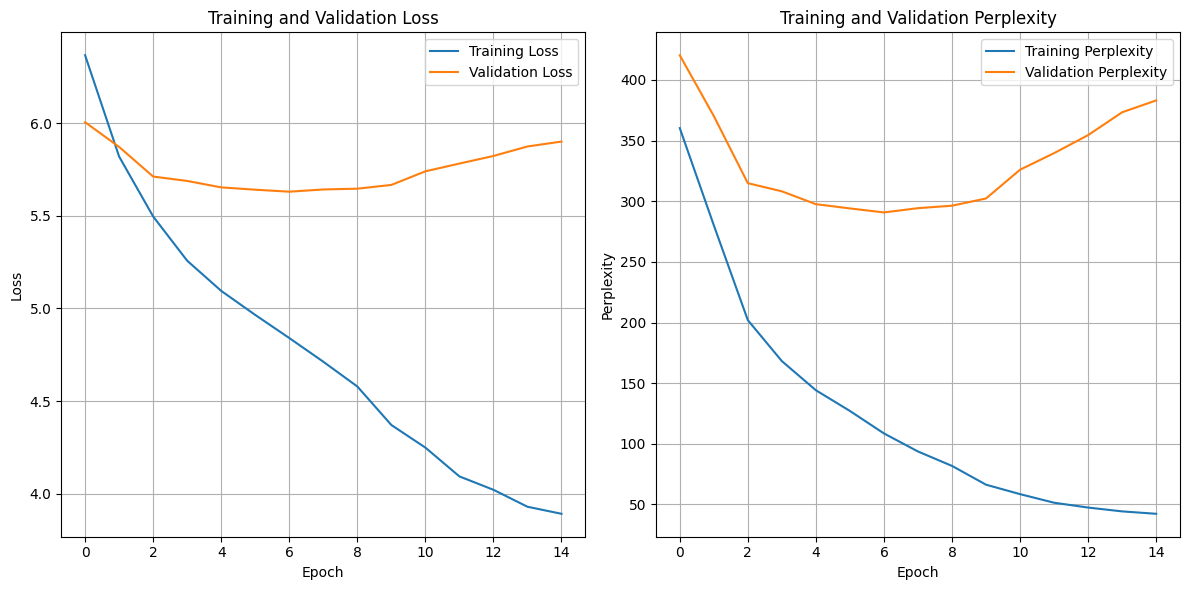

In [ ]:
import matplotlib.pyplot as plt
import math

## Define the Transformer model
class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8, num_layers=6, dim_feedforward=2048, dropout=0.1, max_seq_length=MAX_LEN):
        super(TransformerLM, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_seq_length)
        
        # Create transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        
        self.final_norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        
        self._init_weights()

    def _init_weights(self):
        # Initialize weights with Xavier uniform distribution
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        
        # Special initialization for the final layer
        nn.init.normal_(self.fc_out.weight, mean=0, std=0.02)
        nn.init.zeros_(self.fc_out.bias)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        seq_len = x.size(1)
        
        # Create causal mask for self-attention
        mask = (torch.triu(torch.ones(seq_len, seq_len)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0)).to(x.device)
        
        # Embedding and positional encoding
        x = self.embedding(x) * math.sqrt(self.d_model)  # [batch_size, seq_len, d_model]
        x = self.pos_encoder(x)
        x = self.dropout(x)
        
        # Apply transformer blocks
        attentions = []
        for block in self.transformer_blocks:
            x, attn = block(x, mask)
            attentions.append(attn)
        
        # Final normalization and output projection
        x = self.final_norm(x)
        output = self.fc_out(x)  # [batch_size, seq_len, vocab_size]
        
        return output, attentions


class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attention = MultiHeadAttention(d_model, nhead, dropout)
        
        # Feed forward network
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention with residual connection and layer norm
        attn_output, attention_weights = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed forward with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x, attention_weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % nhead == 0
        
        self.d_model = d_model
        self.nhead = nhead
        self.d_k = d_model // nhead
        
        # Linear projections for Query, Key, Value
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Output projection
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        # Linear projections and split into multiple heads
        q = self.W_q(query).view(batch_size, -1, self.nhead, self.d_k).transpose(1, 2)
        k = self.W_k(key).view(batch_size, -1, self.nhead, self.d_k).transpose(1, 2)
        v = self.W_v(value).view(batch_size, -1, self.nhead, self.d_k).transpose(1, 2)
        
        # Scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Apply mask if provided (for causal attention)
        if mask is not None:
            scores = scores.masked_fill(mask == float('-inf'), float('-inf'))
        
        # Apply softmax and dropout
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # Apply attention weights to values
        context = torch.matmul(attention_weights, v)
        
        # Concatenate heads and apply final linear layer
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(context)
        
        return output, attention_weights


# Add a function to calculate perplexity
def calculate_perplexity(dataset, model, tokenizer, batch_size=32, device=DEVICE):
    """Calculate perplexity on a dataset"""
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer["<PAD>"], reduction='sum')
    total_loss = 0
    total_tokens = 0
    
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Calculating perplexity"):
            tokens = torch.tensor([tokenize(t, pad_to_len=MAX_LEN, tokenizer=tokenizer) for t in batch], dtype=torch.long).to(device)
            src = tokens[:, :-1]
            tgt = tokens[:, 1:]
            
            output, _ = model(src)
            
            # Calculate loss
            loss = criterion(output.contiguous().view(-1, output.size(-1)), tgt.contiguous().view(-1))
            
            # Count non-padding tokens
            non_pad_mask = tgt != tokenizer["<PAD>"]
            num_tokens = non_pad_mask.sum().item()
            
            total_loss += loss.item()
            total_tokens += num_tokens
    
    # Calculate perplexity
    avg_loss = total_loss / total_tokens if total_tokens > 0 else float('inf')
    perplexity = math.exp(avg_loss)
    
    return perplexity


## Modified Training function to include perplexity calculation
def train_model(model, train_loader, val_loader, tokenizer, tokenizer_inv, epochs=10, lr=0.0001, device=DEVICE):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1, verbose=True)
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer["<PAD>"])
    
    best_val_loss = float('inf')
    best_model = None

    train_losses = []
    val_losses = []
    train_perplexities = []
    val_perplexities = []

    # Extract datasets from loaders for perplexity calculation
    train_dataset = train_loader.dataset
    val_dataset = val_loader.dataset

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        # Training loop
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in progress_bar:
            # Process batch
            tokens = torch.tensor([tokenize(t, pad_to_len=MAX_LEN, tokenizer=tokenizer) for t in batch], dtype=torch.long).to(device)
            src = tokens[:, :-1]  # Input sequence
            tgt = tokens[:, 1:]   # Target sequence
            
            # Forward pass
            optimizer.zero_grad()
            output, _ = model(src)
            
            # Calculate loss
            loss = criterion(output.contiguous().view(-1, output.size(-1)), tgt.contiguous().view(-1))
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_train_loss += loss.item()
            progress_bar.set_postfix({"loss": loss.item()})
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation loop
        model.eval()
        with torch.no_grad():
            total_val_loss = 0
            progress_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
            
            for batch in progress_bar:
                tokens = torch.tensor([tokenize(t, pad_to_len=MAX_LEN, tokenizer=tokenizer) for t in batch], dtype=torch.long).to(device)
                src = tokens[:, :-1]
                tgt = tokens[:, 1:]
                
                output, _ = model(src)
                loss = criterion(output.contiguous().view(-1, output.size(-1)), tgt.contiguous().view(-1))
                
                total_val_loss += loss.item()
                progress_bar.set_postfix({"loss": loss.item()})
            
            avg_val_loss = total_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            
            # Calculate perplexity after each epoch
            print(f"Calculating train perplexity for epoch {epoch+1}...")
            train_perplexity = calculate_perplexity(train_dataset, model, tokenizer)
            train_perplexities.append(train_perplexity)
            
            print(f"Calculating validation perplexity for epoch {epoch+1}...")
            val_perplexity = calculate_perplexity(val_dataset, model, tokenizer)
            val_perplexities.append(val_perplexity)
            
            # Update learning rate based on validation loss
            scheduler.step(avg_val_loss)
            
            # Save best model
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
        print(f"Epoch {epoch+1}: Train Perplexity = {train_perplexity:.4f}, Val Perplexity = {val_perplexity:.4f}")

        # Generate a sample text after each epoch
        sample_text = generate_text(model, tokenizer, tokenizer_inv, context="<START>", gen_tokens=50, temperature=0.8)
        
        print(f"Sample text: {sample_text}")
        
        # Save checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'train_perplexity': train_perplexity,
            'val_perplexity': val_perplexity,
        }, f'checkpoint_epoch_{epoch+1}.pt')
    
    # Load best model
    model.load_state_dict(best_model)
    
    return model, train_losses, val_losses, train_perplexities, val_perplexities


def main():
    ## Load and preprocess content
    print("Loading and preprocessing data...")
    train_dataset, val_dataset, tokenizer, tokenizer_inv = load_and_preprocess_data()
    
    ## Create content loaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    ## Model hyperparameters
    vocab_size = len(tokenizer)
    d_model = 512      # Embedding dimension
    nhead = 8          # Number of attention heads
    num_layers = 6    # Number of transformer layers
    dim_feedforward = 2048  # Dimension of feedforward network
    dropout = 0.1      # Dropout rate
    
    ## Initialize model
    print(f"Initializing Transformer model with vocabulary size: {vocab_size}")
    model = TransformerLM(
        vocab_size=vocab_size,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout
    ).to(DEVICE)
    
    ## Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model Parameters: Total = {total_params:,}, Trainable = {trainable_params:,}")
    
    ## Train the model
    print("Starting training...")
    model, train_losses, val_losses, train_perplexities, val_perplexities = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        tokenizer=tokenizer,
        tokenizer_inv=tokenizer_inv,
        epochs=15,
        lr=0.0001,
        device=DEVICE
    )
    
    ## Plot training and validation losses
    print("Plotting training metrics...")
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_perplexities, label='Training Perplexity')
    plt.plot(val_perplexities, label='Validation Perplexity')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.title('Training and Validation Perplexity')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_metrics.png')
    
    ## Save the model
    print("Saving model...")
    torch.save({
        'model_state_dict': model.state_dict(),
        'vocab': tokenizer,
        'config': {
            'd_model': d_model,
            'nhead': nhead,
            'num_layers': num_layers,
            'dim_feedforward': dim_feedforward,
            'dropout': dropout,
            'vocab_size': vocab_size
        },
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_perplexities': train_perplexities,
        'val_perplexities': val_perplexities
    }, 'transformer_shakespeare_model.pt')
    
    ## Evaluate on test content
    print("Evaluating on test data...")
    with open("/raid/home/ganeshb/A3/content/shakespear_test.txt", "r") as f:
        lines_test = f.readlines()
    
    test_dataset = [' '.join(line.split()) for line in lines_test]
    
    print("Calculating final test perplexity...")
    test_perplexity = calculate_perplexity(test_dataset, model, tokenizer, batch_size)
    
    print(f"\nFinal test perplexity: {test_perplexity:.4f}")
    
    # Generate a final sample
    final_sample = generate_text(model, tokenizer, tokenizer_inv, context="<START>", gen_tokens=200, temperature=0.7)
    print(f"\nFinal generated sample:\n{final_sample}")

if __name__ == "__main__":
    main()

In [ ]:
def inference(model_path, test_file, gen_tokens=50, temperature=0.6, device=DEVICE):
    ## Load the saved model
    checkpoint = torch.load(model_path, map_location=device)
    
    # Get model configuration and tokenizer from the saved checkpoint
    config = checkpoint['config']
    tokenizer = checkpoint.get('vocab', None)
    
    # If tokenizer is not in the checkpoint, we need to recreate it
    if tokenizer is None:
        print("Tokenizer not found in checkpoint, recreating from test data...")
        # This is a simplified version - in practice you should use the same tokenizer as training
        with open(test_file, "r") as f:
            lines = f.readlines()
        
        # Create a basic tokenizer from the test data
        all_words = []
        for line in lines:
            all_words.extend(line.split())
        
        # Create vocabulary with special tokens
        special_tokens = ["<PAD>", "<START>", "<STOP>", "<UNK>"]
        vocab = special_tokens + list(set(all_words))
        
        # Create tokenizer
        tokenizer = {word: i for i, word in enumerate(vocab)}
    
    # Create inverse tokenizer for decoding
    tokenizer_inv = {i: word for word, i in tokenizer.items()}
    
    # Initialize model with the same configuration
    model = TransformerLM(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        nhead=config['nhead'],
        num_layers=config['num_layers'],
        dim_feedforward=config['dim_feedforward'],
        dropout=config['dropout']
    ).to(device)
    
    # Load the saved weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    ## Read and process the input from test file
    with open(test_file, "r") as f:
        lines = f.readlines()
    
    test_data = [' '.join(line.split()) for line in lines]
    
    # Calculate perplexity
    losses = evaluate_losses(test_data, model, tokenizer, bs=16)
    perplexity = math.exp(sum(losses) / len(losses))
    
    # Generate text for each input line (use first 10 words as context)
    generated_texts = []
    for line in test_data:
        # Take first few words as context
        words = line.split()
        context = ' '.join(words[:min(10, len(words))])
        
        # Generate continuation
        generated = generate_text(model, tokenizer, tokenizer_inv, 
                                 context=context, 
                                 gen_tokens=gen_tokens, 
                                 temperature=temperature)
        generated_texts.append({
            'context': context,
            'generated': generated
        })
    
    return generated_texts, perplexity, tokenizer, tokenizer_inv

# Usage
model_path = 'transformer_shakespeare_model.pt'
test_file = '/raid/home/ganeshb/A3/content/shakespear_test.txt'
generated_texts, ppl, tokenizer, tokenizer_inv = inference(model_path, test_file)

## Print the generated text and perplexity
print(f"Model perplexity on test data: {ppl:.4f}\n")
print("Generated text samples:")
for i, sample in enumerate(generated_texts):  # Print first 5 samples
    print(f"\nSample {i+1}:")
    print(f"Context: {sample['context']}")
    print(f"Generated: {sample['generated']}")

100%|██████████| 1/1 [00:00<00:00, 58.75it/s]


Model perplexity on test data: 9745.9271

Generated text samples:

Sample 1:
Context: Uneasy lies the head that wears a crown.
Generated: <UNK> lies the head that wears a <UNK> , So we love to make his father : For it I 'll be , the king 's a crown , And not not I live , I see him to be my daughter ; And we had in her of the yielding of his love , whom thou art

Sample 2:
Context: The fault, dear Brutus, is not in our stars, but
Generated: The <UNK> dear <UNK> is not in our <UNK> but many time , And , if I will be make my noble own noble own friends , To make what he would be been in the sea , the heart , with thy love of the noble tongue , say is been , Which with it shall be given divided

Sample 3:
Context: What a piece of work is a man!
Generated: What a piece of work is a <UNK> ?

Sample 4:
Context: If music be the food of love, play on.
Generated: If music be the food of <UNK> play <UNK> , And need I saw thy love , so , and my father should tell you to thee of mine is .

Sample 5